In [1]:
import argparse
import csv
import json
import math
import os
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D
from matplotlib.ticker import LogFormatterMathtext, LogLocator, MultipleLocator
import numpy as np
from numpy.polynomial.legendre import leggauss
import pandas as pd
from scipy.integrate import simpson
from scipy.special import sici

# Keep Matplotlib/font caches writable during notebook and nbconvert runs.
os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(os.environ.get("TMPDIR", "/tmp")) / "polarization_mplconfig"),
)
os.environ.setdefault(
    "XDG_CACHE_HOME",
    str(Path(os.environ.get("TMPDIR", "/tmp")) / "polarization_fontcache"),
)
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)


In [2]:
# ----------------------------
# Shared paths and physical constants
# ----------------------------
RELEASE_DIR = Path.cwd().resolve()
FIG_DIR = RELEASE_DIR / "figs"
DATA_DIR = RELEASE_DIR / "data"
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

HBAR_eVs = 6.582119569e-16
SEC_PER_YEAR = 365.25 * 24.0 * 3600.0
T_OBS_YR = 16.03
MEDIAN_DISTANCE_LY = 4500.9528
DEFAULT_FL = MEDIAN_DISTANCE_LY / T_OBS_YR


# ----------------------------
# Reusable corrected ORF and limiting-integral routines
# ----------------------------
def f_cut_hz(mg_eV: float) -> float:
    """Cutoff frequency from omega >= mg with omega = 2 pi f and omega = E/hbar."""
    return mg_eV / (2.0 * np.pi * HBAR_eVs)

def hellings_downs(xi):
    """Standard Hellings-Downs correlation with HD(0)=0.5."""
    xi = np.asarray(xi, dtype=float)
    x = (1.0 - np.cos(xi)) / 2.0
    out = np.empty_like(x, dtype=float)
    small = x <= 0.0
    out[small] = 0.5
    out[~small] = 0.5 + 1.5 * x[~small] * np.log(x[~small]) - 0.25 * x[~small]
    return out

def mass_ratio_from_A(A):
    """Return alpha = m/omega = sqrt(1 - A^2), clipped for roundoff."""
    return np.sqrt(np.maximum(0.0, 1.0 - np.asarray(A, dtype=float) ** 2))

def liang_omega_ratios(A, n_V=0.0, n_S=0.0, C_V=1.0, C_S=1.0):
    """Liang-basis ratios: Omega_V/Omega_T=C_V alpha^(2+n_V), Omega_S/Omega_T=C_S alpha^(4+n_S)."""
    alpha = mass_ratio_from_A(A)
    return C_V * alpha ** (2.0 + n_V), C_S * alpha ** (4.0 + n_S)

def _draw_angles(num_samples: int, seed: int):
    rng = np.random.default_rng(seed)
    theta = rng.uniform(0.0, np.pi, int(num_samples))
    phi = rng.uniform(0.0, 2.0 * np.pi, int(num_samples))
    return {
        "theta": theta,
        "phi": phi,
        "cos_theta": np.cos(theta),
        "sin_theta": np.sin(theta),
        "cos_phi": np.cos(phi),
        "sin_phi": np.sin(phi),
    }

def _proj(angles, xi):
    return (
        angles["cos_theta"] * float(np.cos(xi))
        + angles["cos_phi"] * angles["sin_theta"] * float(np.sin(xi))
    )

def _phase_prod(angles, A, xi, fL1, fL2):
    mu_a = angles["cos_theta"]
    mu_b = _proj(angles, xi)
    return (
        np.exp(1j * 2.0 * np.pi * fL1 * (1.0 + A * mu_a)) - 1.0
    ) * (
        np.exp(-1j * 2.0 * np.pi * fL2 * (1.0 + A * mu_b)) - 1.0
    )

def tensor_kernel(angles, A, xi):
    cos_theta = angles["cos_theta"]
    sin_theta = angles["sin_theta"]
    cos_phi = angles["cos_phi"]
    sin_phi = angles["sin_phi"]
    cos_xi = float(np.cos(xi))
    sin_xi = float(np.sin(xi))
    mu_b = _proj(angles, xi)

    numerator = (
        cos_xi**2 * sin_theta**2
        - 2.0 * cos_theta * sin_theta * cos_xi * sin_xi * cos_phi
        + sin_xi**2 * (cos_theta**2 * cos_phi**2 - sin_phi**2)
    )
    return (sin_theta**2 / (2.0 * (1.0 + A * cos_theta))) * (numerator / (1.0 + A * mu_b))

def integrand_expression_V_reuse(cos_theta, sin_theta, cos_phi, sin_phi, A, cos_xi, sin_xi):
    """Correct Liang-matching vector kernel, without Jacobian, phases, or beta prefactor."""
    _ = sin_phi
    proj = cos_theta * cos_xi + cos_phi * sin_theta * sin_xi
    denom = (1.0 + A * cos_theta) * (1.0 + A * proj)

    fac_a = -A + (A**2 + 2.0) * cos_theta
    fac_b = cos_xi * sin_theta - cos_theta * cos_phi * sin_xi
    fac_c = -A + (A**2 + 2.0) * proj
    return fac_a * sin_theta * fac_b * fac_c / denom

def vector_kernel(angles, A, xi):
    return integrand_expression_V_reuse(
        angles["cos_theta"],
        angles["sin_theta"],
        angles["cos_phi"],
        angles["sin_phi"],
        A,
        float(np.cos(xi)),
        float(np.sin(xi)),
    )

def integrand_vector_liang(cos_theta, sin_theta, cos_phi, sin_phi, A, cos_xi, sin_xi):
    """Old literal Liang-derived vector kernel using the pre-correction sign convention."""
    _ = sin_phi
    proj = cos_theta * cos_xi + cos_phi * sin_theta * sin_xi
    denom = (1.0 + A * cos_theta) * (1.0 + A * proj)

    fac_a = -A + (A**2 - 2.0) * cos_theta
    fac_b = cos_xi * sin_theta - cos_theta * cos_phi * sin_xi
    fac_c = -A + (A**2 - 2.0) * proj
    return fac_a * sin_theta * fac_b * fac_c / denom

def integrand_scalar_mathematica(cos_theta, sin_theta, cos_phi, sin_phi, A, cos_xi, sin_xi):
    """Corrected scalar kernel from the plus-sign longitudinal convention."""
    _ = sin_phi
    mu_a = cos_theta
    mu_b = cos_theta * cos_xi + cos_phi * sin_theta * sin_xi
    alpha2 = 1.0 - A**2
    denom = alpha2**2 * (1.0 + A * mu_a) * (1.0 + A * mu_b)

    def corrected_factor(mu):
        return A**2 - 1.0 - 2.0 * A * (1.0 + A**2) * mu + (3.0 + A**2) * mu**2

    return corrected_factor(mu_a) * corrected_factor(mu_b) / denom

def integrand_scalar_mathematica_stable(cos_theta, sin_theta, cos_phi, sin_phi, A, cos_xi, sin_xi):
    """Backward-compatible name for the corrected scalar kernel."""
    return integrand_scalar_mathematica(cos_theta, sin_theta, cos_phi, sin_phi, A, cos_xi, sin_xi)

def integrand_scalar_liang(cos_theta, sin_theta, cos_phi, sin_phi, A, cos_xi, sin_xi):
    """Old literal Liang-derived scalar expression, simplified only by trig identities."""
    _ = sin_phi
    cos_2theta = 2.0 * cos_theta**2 - 1.0
    cos_2xi = 2.0 * cos_xi**2 - 1.0
    numerator = 1.0 + 4.0 * A * cos_theta + 3.0 * cos_2theta
    denom = (1.0 + A * cos_theta) * (1.0 + A * (cos_theta * cos_xi + cos_phi * sin_theta * sin_xi))
    poly_term = (
        (-2.0 + 6.0 * cos_2theta + 6.0 * cos_2xi + 6.0 * cos_2theta * cos_2xi + 16.0 * A * cos_theta * cos_xi) / 8.0
        + 2.0 * (A + 3.0 * cos_theta * cos_xi) * sin_theta * sin_xi * cos_phi
        + 3.0 * sin_theta**2 * sin_xi**2 * cos_phi**2
    )
    return 0.5 * numerator * poly_term / denom

def scalar_kernel(angles, A, xi):
    return integrand_scalar_mathematica(
        angles["cos_theta"],
        angles["sin_theta"],
        angles["cos_phi"],
        angles["sin_phi"],
        A,
        float(np.cos(xi)),
        float(np.sin(xi)),
    )

def _gamma_sector(kernel_fn, prefactor, A, xi_values, fL1, fL2, num_samples, seed):
    angles = _draw_angles(num_samples, seed)
    area = 2.0 * np.pi**2
    xi_values = np.asarray(xi_values, dtype=float)
    out = np.empty(len(xi_values), dtype=float)
    for i, xi in enumerate(xi_values):
        vals = kernel_fn(angles, float(A), float(xi)) * angles["sin_theta"] * _phase_prod(angles, float(A), float(xi), fL1, fL2)
        out[i] = np.real(prefactor * np.mean(vals) * area)
    return out

def Gamma_T(beta_T, A, xi_values, fL1, fL2, num_samples=25000, seed=0):
    return _gamma_sector(tensor_kernel, beta_T / 4.0, A, xi_values, fL1, fL2, num_samples, seed)

def Gamma_V(beta_V, k_abs_k_0, xi_values, fL1, fL2, num_samples=150000, seed=0):
    A = float(k_abs_k_0)
    return _gamma_sector(vector_kernel, beta_V / (8.0 * (1.0 - A**2)), A, xi_values, fL1, fL2, num_samples, seed)

def Gamma_S(beta_S, k_abs_k_0, xi_values, fL1, fL2, num_samples=150000, seed=0):
    return _gamma_sector(scalar_kernel, beta_S / 24.0, k_abs_k_0, xi_values, fL1, fL2, num_samples, seed)

def Gamma_S_liang(beta_S, k_abs_k_0, xi_values, fL1, fL2, num_samples=150000, seed=0):
    def kernel(angles, A, xi):
        return integrand_scalar_liang(
            angles["cos_theta"], angles["sin_theta"], angles["cos_phi"], angles["sin_phi"],
            A, float(np.cos(xi)), float(np.sin(xi))
        )
    return _gamma_sector(kernel, beta_S / 24.0, k_abs_k_0, xi_values, fL1, fL2, num_samples, seed)

def phase_prod_colinear(A, mu, fL1, fL2):
    return (
        np.exp(1j * 2.0 * np.pi * fL1 * (1.0 + A * mu)) - 1.0
    ) * (
        np.exp(-1j * 2.0 * np.pi * fL2 * (1.0 + A * mu)) - 1.0
    )

def phase_sq_auto(A, mu, fL):
    phase = 2.0 * np.pi * fL * (1.0 + A * mu)
    return 2.0 - 2.0 * np.cos(phase)

def _auto_mu(num_samples, seed):
    rng = np.random.default_rng(seed)
    theta = rng.uniform(0.0, np.pi, int(num_samples))
    return np.cos(theta), np.sin(theta)

def Gamma_T_auto_raw(A, fL, num_samples=25000, seed=0):
    mu, s = _auto_mu(num_samples, seed)
    kernel = s**4 / (2.0 * (1.0 + A * mu) ** 2)
    return np.real((1.0 / 4.0) * np.mean(kernel * phase_sq_auto(A, mu, fL) * s) * 2.0 * np.pi**2)

def Gamma_HD_auto_raw(fL, num_samples=25000, seed=0):
    mu, s = _auto_mu(num_samples, seed)
    kernel = 0.5 * (1.0 - mu) ** 2
    return np.real((1.0 / 4.0) * np.mean(kernel * phase_sq_auto(1.0, mu, fL) * s) * 2.0 * np.pi**2)

def Gamma_V_auto_raw(A, fL, num_samples=25000, seed=0):
    mu, s = _auto_mu(num_samples, seed)
    fac = (A**2 + 2.0) * mu - A
    kernel = fac**2 * s**2 / (1.0 + A * mu) ** 2
    return np.real((1.0 / (8.0 * (1.0 - A**2))) * np.mean(kernel * phase_sq_auto(A, mu, fL) * s) * 2.0 * np.pi**2)

def Gamma_S_auto_raw(A, fL, num_samples=25000, seed=0):
    mu, s = _auto_mu(num_samples, seed)
    alpha2 = 1.0 - A**2
    B = A**2 - 1.0 - 2.0 * A * (1.0 + A**2) * mu + (3.0 + A**2) * mu**2
    kernel = B**2 / (alpha2**2 * (1.0 + A * mu) ** 2)
    return np.real((1.0 / 24.0) * np.mean(kernel * phase_sq_auto(A, mu, fL) * s) * 2.0 * np.pi**2)

def Gamma_V_auto_raw_liang(A, fL, num_samples=25000, seed=0):
    mu, s = _auto_mu(num_samples, seed)
    fac = (A**2 - 2.0) * mu - A
    kernel = fac**2 * s**2 / (1.0 + A * mu) ** 2
    return np.real((1.0 / (8.0 * (1.0 - A**2))) * np.mean(kernel * phase_sq_auto(A, mu, fL) * s) * 2.0 * np.pi**2)

def Gamma_S_auto_raw_liang(A, fL, num_samples=25000, seed=0):
    mu, s = _auto_mu(num_samples, seed)
    B = 1.0 - 2.0 * A * mu - 3.0 * mu**2
    kernel = B**2 / (1.0 + A * mu) ** 2
    return np.real((1.0 / 24.0) * np.mean(kernel * phase_sq_auto(A, mu, fL) * s) * 2.0 * np.pi**2)

def Gamma_HD_raw(xi_values, fL1, fL2, num_samples=25000, seed=0):
    return Gamma_T(1.0, 1.0, xi_values, fL1, fL2, num_samples=num_samples, seed=seed)

def Gamma_eff_auto_raw(A, fL, Omega_T=1.0, Omega_V=0.0, Omega_S=0.0, num_samples=25000, seed=0):
    return (
        Gamma_T_auto_raw(A, fL, num_samples=num_samples, seed=seed)
        + (Omega_V / Omega_T) * Gamma_V_auto_raw(A, fL, num_samples=num_samples, seed=seed)
        + (Omega_S / Omega_T) * Gamma_S_auto_raw(A, fL, num_samples=num_samples, seed=seed)
    )

def effective_pair_beta(A, fL1, fL2, Omega_T=1.0, Omega_V=0.0, Omega_S=0.0, num_samples=25000, seed=0):
    """Pair normalization beta = 1 / sqrt(Gamma_aa Gamma_bb), using corrected autocorrelations."""
    g_aa = Gamma_eff_auto_raw(A, fL1, Omega_T, Omega_V, Omega_S, num_samples=num_samples, seed=seed)
    g_bb = Gamma_eff_auto_raw(A, fL2, Omega_T, Omega_V, Omega_S, num_samples=num_samples, seed=seed)
    den = float(np.real(g_aa) * np.real(g_bb))
    if (not np.isfinite(den)) or den <= 0.0:
        raise ValueError(f"Bad autocorrelation normalization: Gamma_aa={g_aa}, Gamma_bb={g_bb}")
    return 1.0 / np.sqrt(den)

def Gamma_eff_auto_raw_liang(A, fL, Omega_T=1.0, Omega_V=0.0, Omega_S=0.0, num_samples=25000, seed=0):
    return (
        Gamma_T_auto_raw(A, fL, num_samples=num_samples, seed=seed)
        + (Omega_V / Omega_T) * Gamma_V_auto_raw_liang(A, fL, num_samples=num_samples, seed=seed)
        + (Omega_S / Omega_T) * Gamma_S_auto_raw_liang(A, fL, num_samples=num_samples, seed=seed)
    )

def effective_pair_beta_liang(A, fL1, fL2, Omega_T=1.0, Omega_V=0.0, Omega_S=0.0, num_samples=25000, seed=0):
    """Pair normalization beta using old literal Liang autocorrelations."""
    g_aa = Gamma_eff_auto_raw_liang(A, fL1, Omega_T, Omega_V, Omega_S, num_samples=num_samples, seed=seed)
    g_bb = Gamma_eff_auto_raw_liang(A, fL2, Omega_T, Omega_V, Omega_S, num_samples=num_samples, seed=seed)
    den = float(np.real(g_aa) * np.real(g_bb))
    if (not np.isfinite(den)) or den <= 0.0:
        raise ValueError(f"Bad Liang autocorrelation normalization: Gamma_aa={g_aa}, Gamma_bb={g_bb}")
    return 1.0 / np.sqrt(den)

def hd_pair_beta(fL1, fL2, num_samples=25000, seed=0):
    g_aa = Gamma_HD_auto_raw(fL1, num_samples=num_samples, seed=seed)
    g_bb = Gamma_HD_auto_raw(fL2, num_samples=num_samples, seed=seed)
    return 1.0 / np.sqrt(float(np.real(g_aa) * np.real(g_bb)))

def Gamma_T_tilde(beta_T, beta_V, beta_S, Omega_T, Omega_V, Omega_S, k_abs_k_0, xi_values, fL1, fL2, num_samples=150000, seed=0):
    """
    Effective Liang-basis ORF contribution with corrected vector/scalar kernels.

    Backward compatibility: historical cells normalized with
    1/Gamma_T_tilde(..., xi_values=[tiny angle], ...).  For unit beta arguments
    and a single tiny xi this returns sqrt(Gamma_aa Gamma_bb), so those cells now
    use autocorrelation normalization instead of a cross-correlation at xi≈0.
    """
    xi_arr = np.asarray(xi_values, dtype=float)
    GT = Gamma_T(beta_T, k_abs_k_0, xi_arr, fL1, fL2, num_samples, seed)
    GV = Gamma_V(beta_V, k_abs_k_0, xi_arr, fL1, fL2, num_samples, seed)
    GS = Gamma_S(beta_S, k_abs_k_0, xi_arr, fL1, fL2, num_samples, seed)
    return GT + GV * Omega_V / Omega_T * beta_T / beta_V + GS * Omega_S / Omega_T * beta_T / beta_S

def normalized_components(A, xi_values, fL1, fL2, Omega_T=1.0, Omega_V=0.0, Omega_S=0.0, num_samples=25000, beta_samples=25000, seed=0):
    beta = effective_pair_beta(A, fL1, fL2, Omega_T, Omega_V, Omega_S, num_samples=beta_samples, seed=seed)
    gamma_T = Gamma_T(beta, A, xi_values, fL1, fL2, num_samples=num_samples, seed=seed)
    raw_V = Gamma_V(1.0, A, xi_values, fL1, fL2, num_samples=num_samples, seed=seed)
    raw_S = Gamma_S(1.0, A, xi_values, fL1, fL2, num_samples=num_samples, seed=seed)
    gamma_V = beta * (Omega_V / Omega_T) * raw_V
    gamma_S = beta * (Omega_S / Omega_T) * raw_S
    return beta, gamma_T, gamma_V, gamma_S, gamma_T + gamma_V + gamma_S


# Figure 1 angular-integral routines
def make_quadrature(n_mu: int, n_phi: int) -> dict[str, np.ndarray]:
    mu_1d, w_mu_1d = np.polynomial.legendre.leggauss(n_mu)
    phi_1d = (np.arange(n_phi, dtype=float) + 0.5) * (2.0 * np.pi / n_phi)
    mu = mu_1d[:, None]
    phi = phi_1d[None, :]
    sin_theta = np.sqrt(np.maximum(0.0, 1.0 - mu**2))
    return {
        "mu": mu,
        "sin_theta": sin_theta,
        "cos_phi": np.cos(phi),
        "sin_phi": np.sin(phi),
        "weights": w_mu_1d[:, None] * np.full((1, n_phi), 2.0 * np.pi / n_phi),
    }

def old_liang_vector_kernel(mu: np.ndarray, sin_theta: np.ndarray, cos_phi: np.ndarray, xi: float, a: float) -> np.ndarray:
    cos_xi = np.cos(xi)
    sin_xi = np.sin(xi)
    proj = mu * cos_xi + cos_phi * sin_theta * sin_xi
    denom = (1.0 + a * mu) * (1.0 + a * proj)
    fac_1 = (a**2 - 2.0) * mu - a
    fac_2 = cos_xi * sin_theta - mu * cos_phi * sin_xi
    fac_3 = (a**2 - 2.0) * proj - a
    return fac_1 * sin_theta * fac_2 * fac_3 / denom

def old_liang_scalar_kernel(mu: np.ndarray, sin_theta: np.ndarray, cos_phi: np.ndarray, xi: float, a: float) -> np.ndarray:
    cos_xi = np.cos(xi)
    sin_xi = np.sin(xi)
    proj = mu * cos_xi + cos_phi * sin_theta * sin_xi
    denom = (1.0 + a * mu) * (1.0 + a * proj)
    first = 1.0 - 2.0 * a * mu - 3.0 * mu**2
    second = 1.0 - 2.0 * a * proj - 3.0 * proj**2
    return first * second / denom

def isi_vector_kernel(mu: np.ndarray, sin_theta: np.ndarray, cos_phi: np.ndarray, xi: float, a: float) -> np.ndarray:
    cos_xi = np.cos(xi)
    sin_xi = np.sin(xi)
    proj = mu * cos_xi + cos_phi * sin_theta * sin_xi
    denom = (1.0 + a * mu) * (1.0 + a * proj)
    fac_1 = (a**2 + 2.0) * mu - a
    fac_2 = cos_xi * sin_theta - mu * cos_phi * sin_xi
    fac_3 = (a**2 + 2.0) * proj - a
    return fac_1 * sin_theta * fac_2 * fac_3 / denom

def isi_scalar_kernel(mu: np.ndarray, sin_theta: np.ndarray, cos_phi: np.ndarray, xi: float, a: float) -> np.ndarray:
    cos_xi = np.cos(xi)
    sin_xi = np.sin(xi)
    proj = mu * cos_xi + cos_phi * sin_theta * sin_xi
    denom = (1.0 + a * mu) * (1.0 + a * proj)

    def numerator(q: np.ndarray) -> np.ndarray:
        return (1.0 - a**2) + 2.0 * a * (1.0 + a**2) * q - (a**2 + 3.0) * q**2

    return numerator(mu) * numerator(proj) / denom

def liang_tensor_kernel(mu: np.ndarray, sin_theta: np.ndarray, cos_phi: np.ndarray, xi: float, a: float) -> np.ndarray:
    cos_xi = np.cos(xi)
    sin_xi = np.sin(xi)
    proj = mu * cos_xi + cos_phi * sin_theta * sin_xi
    numerator = (
        cos_xi**2 * sin_theta**2
        - 2.0 * mu * sin_theta * cos_xi * sin_xi * cos_phi
        + sin_xi**2 * (mu**2 * cos_phi**2 - (1.0 - cos_phi**2))
    )
    return sin_theta**2 * numerator / (2.0 * (1.0 + a * mu) * (1.0 + a * proj))

def normalize_to_xi0(values: np.ndarray) -> np.ndarray:
    denom = values[0]
    if not np.isfinite(denom) or np.isclose(denom, 0.0):
        raise ValueError(f"Cannot normalize curve with xi=0 value {denom!r}")
    return values / denom

def liang_l1(speed_ratio: float, cos_xi: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Liang--Trodden Eq. (37), together with its square-root denominator."""
    a = speed_ratio
    root = np.sqrt(
        np.maximum(0.0, (1.0 - cos_xi) * (2.0 - a**2 * (1.0 + cos_xi)))
    )
    numerator = (
        1.0
        + 2.0 * a**2 * (1.0 - 2.0 * cos_xi)
        - a**4 * (1.0 - 2.0 * cos_xi**2)
        - 2.0 * a * (1.0 - a**2 * cos_xi) * root
    )
    l1 = numerator**2 / (1.0 - a**2) ** 4
    return l1, root

def liang_analytic_earth_term(
    sector: str, speed_ratio: float, xi_values: np.ndarray
) -> np.ndarray:
    """Liang--Trodden analytic Earth-term ORFs, Eqs. (36), (42), and (46).

    The overall beta normalization is set to one; it cancels when every curve is
    normalized to Gamma(0)=1/2 below.  Eq. (37) is singular in this form at
    xi=0, so that endpoint is supplied by direct Earth-term quadrature.
    """
    a = speed_ratio
    c = np.cos(xi_values)
    l1, root = liang_l1(a, c)
    valid = root > 1.0e-12
    log_l1_over_root = np.empty_like(root)
    log_l1_over_root[valid] = np.log(l1[valid]) / root[valid]
    log_l1_over_root[~valid] = np.nan

    if sector == "tensor":
        bracket = (
            4.0 * a * (-3.0 + (-6.0 + 5.0 * a**2) * c)
            + 12.0
            * (1.0 + c + a**2 * (1.0 - 3.0 * c))
            * np.log((1.0 + a) / (1.0 - a))
            + 3.0
            * (1.0 + 2.0 * a**2 * (1.0 - 2.0 * c) - a**4 * (1.0 - 2.0 * c**2))
            * log_l1_over_root
        )
        return -np.pi * bracket / (24.0 * a**5)

    if sector == "vector":
        bracket = (
            a
            / 3.0
            * (
                a**6 * c
                - 2.0 * a**4 * (5.0 * c + 3.0)
                + 2.0 * a**2 * (11.0 * c + 6.0)
                - 6.0 * (2.0 * c + 1.0)
            )
            + (a**2 - 1.0) ** 2
            * ((a**2 - 2.0) * c - 2.0)
            * np.log((1.0 - a) / (1.0 + a))
            + 0.5
            * (a**2 - 1.0) ** 2
            * (1.0 - a**2 * c)
            * log_l1_over_root
        )
        return np.pi * bracket / (a**5 * (1.0 - a**2))

    if sector == "scalar":
        bracket = (
            4.0 * a * (9.0 + 4.0 * a**4 + 18.0 * c - 3.0 * a**2 * (4.0 + 5.0 * c))
            - 12.0
            * (1.0 - a**2)
            * (2.0 * a**2 - 3.0 - 3.0 * c)
            * np.log((1.0 - a) / (1.0 + a))
            - 9.0 * (1.0 - a**2) ** 2 * log_l1_over_root
        )
        return np.pi * bracket / (24.0 * a**5)

    raise ValueError(f"unknown sector: {sector}")

def liang_earth_term_quadrature(
    sector: str,
    speed_ratio: float,
    xi_values: np.ndarray,
    quad: dict[str, np.ndarray],
) -> np.ndarray:
    """Direct check of Liang's Earth-term integrals before analytic evaluation."""
    alpha2 = 1.0 - speed_ratio**2
    if sector == "tensor":
        kernel_fn = liang_tensor_kernel
        prefactor = 1.0 / 4.0
    elif sector == "vector":
        kernel_fn = old_liang_vector_kernel
        prefactor = 1.0 / (8.0 * alpha2)
    elif sector == "scalar":
        kernel_fn = old_liang_scalar_kernel
        prefactor = 1.0 / 24.0
    else:
        raise ValueError(f"unknown sector: {sector}")

    weights = quad["weights"]
    out = np.empty(len(xi_values), dtype=float)
    for i, xi in enumerate(xi_values):
        kernel = kernel_fn(
            quad["mu"], quad["sin_theta"], quad["cos_phi"], xi, speed_ratio
        )
        out[i] = np.real(prefactor * np.sum(weights * kernel))
    return out

def normalized_liang_earth_curves(
    sector: str,
    xi_values: np.ndarray,
    quad: dict[str, np.ndarray],
) -> dict[float, np.ndarray]:
    """Liang Earth-term curves, each normalized to Gamma(0)=1/2."""
    curves: dict[float, np.ndarray] = {}
    for vg in VG_VALUES:
        analytic = liang_analytic_earth_term(sector, vg, xi_values)
        analytic[0] = liang_earth_term_quadrature(
            sector, vg, np.asarray([0.0]), quad
        )[0]
        curves[vg] = 0.5 * normalize_to_xi0(analytic)
    return curves

def isi_earth_term_quadrature(
    sector: str,
    speed_ratio: float,
    xi_values: np.ndarray,
    quad: dict[str, np.ndarray],
) -> np.ndarray:
    """Our PTA ORFs in the Isi--Stein basis, with no pulsar terms."""
    if sector == "tensor":
        kernel_fn = liang_tensor_kernel
        prefactor = 1.0 / 4.0
    elif sector == "vector":
        kernel_fn = isi_vector_kernel
        prefactor = 1.0 / 4.0
    elif sector == "scalar":
        kernel_fn = isi_scalar_kernel
        prefactor = 1.0 / 16.0
    else:
        raise ValueError(f"unknown sector: {sector}")

    weights = quad["weights"]
    out = np.empty(len(xi_values), dtype=float)
    for i, xi in enumerate(xi_values):
        kernel = kernel_fn(
            quad["mu"], quad["sin_theta"], quad["cos_phi"], xi, speed_ratio
        )
        out[i] = np.real(prefactor * np.sum(weights * kernel))
    return out

def normalized_isi_earth_curves(
    sector: str,
    xi_values: np.ndarray,
    quad: dict[str, np.ndarray],
) -> dict[float, np.ndarray]:
    """Our Isi--Stein-basis PTA ORFs, each normalized to Gamma(0)=1/2."""
    curves: dict[float, np.ndarray] = {}
    for vg in VG_VALUES:
        earth_term = isi_earth_term_quadrature(sector, vg, xi_values, quad)
        curves[vg] = 0.5 * normalize_to_xi0(earth_term)
    return curves

def verify_liang_analytic_expressions(quad: dict[str, np.ndarray]) -> None:
    """Numerically verify paper Eqs. (36), (42), and (46) at regular angles."""
    check_xi = np.radians(np.asarray([17.0, 53.0, 101.0, 157.0]))
    for sector in ("tensor", "vector", "scalar"):
        for vg in VG_VALUES:
            analytic = liang_analytic_earth_term(sector, vg, check_xi)
            numeric = liang_earth_term_quadrature(sector, vg, check_xi, quad)
            # Eq. (36) has subtractive cancellation at A=0.99 in float64;
            # the remaining cases agree much more tightly than this bound.
            if not np.allclose(analytic, numeric, rtol=1.0e-6, atol=1.0e-8):
                error = float(np.max(np.abs(analytic - numeric)))
                raise AssertionError(
                    f"Liang analytic check failed for {sector}, vg={vg}: {error:.3e}"
                )


# Figure 5 finite-distance angular integral
def response_factor(mu: np.ndarray, f_l: float) -> np.ndarray:
    """Massless-limit pulsar response with the removable x=0 limit included."""
    x = 1.0 + mu
    phase = 2.0 * np.pi * f_l
    out = np.empty_like(x, dtype=complex)
    small = np.abs(x) < 1.0e-10
    out[small] = 1j * phase
    out[~small] = (np.exp(1j * phase * x[~small]) - 1.0) / x[~small]
    return out

def corrected_finite_distance_coefficients(
    xi_rad: np.ndarray, f_l: float = DEFAULT_FL
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return T, (1-v_g^2)V, and (1-v_g^2)^2 S coefficient functions."""
    from numpy.polynomial.legendre import leggauss

    mu, weights = leggauss(360)
    phi = np.linspace(0.0, 2.0 * np.pi, 540, endpoint=False)
    dphi = 2.0 * np.pi / len(phi)

    cos_theta = mu[:, None]
    sin_theta = np.sqrt(np.maximum(0.0, 1.0 - mu**2))[:, None]
    cos_phi = np.cos(phi)[None, :]
    sin_phi = np.sin(phi)[None, :]
    response_a = response_factor(cos_theta, f_l)

    tensor = np.empty_like(xi_rad, dtype=float)
    vector = np.empty_like(xi_rad, dtype=float)
    scalar = np.empty_like(xi_rad, dtype=float)

    for i, xi in enumerate(xi_rad):
        cos_xi = float(np.cos(xi))
        sin_xi = float(np.sin(xi))
        mu_b = cos_theta * cos_xi + cos_phi * sin_theta * sin_xi
        response_b = np.conj(response_factor(mu_b, f_l))

        tensor_angular = (
            sin_theta**2
            / 2.0
            * (
                (cos_xi * sin_theta - cos_theta * cos_phi * sin_xi) ** 2
                - sin_xi**2 * sin_phi**2
            )
        )
        vector_angular = (
            (-1.0 + 3.0 * cos_theta)
            * sin_theta
            * (cos_xi * sin_theta - cos_theta * cos_phi * sin_xi)
            * (-1.0 + 3.0 * mu_b)
        )
        scalar_angular = 16.0 * cos_theta * (cos_theta - 1.0) * mu_b * (mu_b - 1.0)

        common = response_a * response_b
        tensor[i] = np.real(0.25 * np.sum(weights * np.sum(tensor_angular * common, axis=1) * dphi))
        vector[i] = np.real(0.125 * np.sum(weights * np.sum(vector_angular * common, axis=1) * dphi))
        scalar[i] = np.real((1.0 / 24.0) * np.sum(weights * np.sum(scalar_angular * common, axis=1) * dphi))

    return tensor, vector, scalar


# Figures 6 and 7 exact finite-fL autocorrelation integrals
def autocorrelation_vg1_rescaled(f_l: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    f_l = np.asarray(f_l, dtype=float)
    K = 2.0 * np.pi * f_l
    si, ci = sici(2.0 * K)
    log_integral = np.euler_gamma + np.log(2.0 * K) - ci
    inverse_square_integral = K * si - 0.5 * (1.0 - np.cos(2.0 * K))

    tensor = np.pi * (
        4.0 / 3.0
        - 2.0 / K**2
        + np.sin(2.0 * K) / K**3
    )
    vector = np.pi / 2.0 * (
        -68.0
        + 32.0 * log_integral
        + 16.0 * np.sin(2.0 * K) / K
        + (42.0 - 6.0 * np.cos(2.0 * K)) / K**2
        - 18.0 * np.sin(2.0 * K) / K**3
    )
    scalar = 8.0 * np.pi / 3.0 * (
        50.0 / 3.0
        - 5.0 * np.sin(2.0 * K) / K
        - (6.0 - 2.0 * np.cos(2.0 * K)) / K**2
        + 2.0 * np.sin(2.0 * K) / K**3
        - 12.0 * log_integral
        + 4.0 * inverse_square_integral
    )
    return tensor, vector, scalar

def one_minus_cos_integral_power(power: int, y: np.ndarray, k: float) -> np.ndarray:
    y = np.asarray(y, dtype=float)
    if power == -2:
        si, _ = sici(k * y)
        return k * si - (1.0 - np.cos(k * y)) / y
    if power == -1:
        _, ci = sici(k * y)
        return np.euler_gamma + np.log(k * y) - ci
    if power == 0:
        return y - np.sin(k * y) / k
    if power == 1:
        return 0.5 * y**2 - y * np.sin(k * y) / k - np.cos(k * y) / k**2
    if power == 2:
        return (
            y**3 / 3.0
            - y**2 * np.sin(k * y) / k
            - 2.0 * y * np.cos(k * y) / k**2
            + 2.0 * np.sin(k * y) / k**3
        )
    raise ValueError(f"unsupported power {power}")

def integrate_kernel_polynomial(coeffs: np.ndarray, y_min: np.float64, y_max: np.float64, k: np.float64) -> np.float64:
    total = np.float64(0.0)
    bounds = np.asarray([y_min, y_max], dtype=np.float64)
    for degree, coeff in enumerate(coeffs):
        power = degree - 2
        primitive = one_minus_cos_integral_power(power, bounds, k)
        total += coeff * (primitive[1] - primitive[0])
    return np.float64(total)

def rescaled_autocorrelation_from_bounds(
    f_l: np.float64,
    v_g: np.float64,
    v_g_squared: np.float64,
    y_min: np.float64,
    y_max: np.float64,
) -> tuple[np.float64, np.float64, np.float64]:
    y_poly = np.polynomial.Polynomial([0.0, 1.0])
    mu_poly = (y_poly - 1.0) / v_g
    tensor_poly = 0.5 * (1.0 - mu_poly**2) ** 2
    vector_poly = (1.0 - mu_poly**2) * (-v_g + (v_g_squared + 2.0) * mu_poly) ** 2
    scalar_piece_poly = (
        (1.0 - v_g_squared)
        + 2.0 * v_g * (1.0 + v_g_squared) * mu_poly
        - (v_g_squared + 3.0) * mu_poly**2
    )
    scalar_poly = scalar_piece_poly**2

    k = np.float64(2.0 * np.pi * f_l)

    tensor_integral = integrate_kernel_polynomial(tensor_poly.coef, y_min, y_max, k)
    vector_integral = integrate_kernel_polynomial(vector_poly.coef, y_min, y_max, k)
    scalar_integral = integrate_kernel_polynomial(scalar_poly.coef, y_min, y_max, k)

    tensor = np.pi / v_g * tensor_integral
    vector = np.pi / (2.0 * v_g) * vector_integral
    scalar = np.pi / (6.0 * v_g) * scalar_integral
    return np.float64(tensor), np.float64(vector), np.float64(scalar)

def rescaled_autocorrelation_exact(f_l: float, v_g: float) -> tuple[np.float64, np.float64, np.float64]:
    v_g = np.float64(v_g)
    v_g_squared = np.float64(v_g * v_g)
    return rescaled_autocorrelation_from_bounds(
        np.float64(f_l),
        v_g,
        v_g_squared,
        np.float64(1.0 - v_g),
        np.float64(1.0 + v_g),
    )

def rescaled_autocorrelation_one_minus_v(
    f_l: float,
    one_minus_v: float,
) -> tuple[np.float64, np.float64, np.float64]:
    y_min = np.float64(one_minus_v)
    v_g = np.float64(1.0 - y_min)
    v_g_squared = np.float64(v_g * v_g)
    y_max = np.float64(1.0 + v_g)
    return rescaled_autocorrelation_from_bounds(
        np.float64(f_l),
        v_g,
        v_g_squared,
        y_min,
        y_max,
    )


# Figure 8 regularized tensor/vector/scalar ORF integrals
def f_l_from_frequency_distance(f_nhz: float, l_ly: float) -> float:
    return float(f_nhz) * 1.0e-9 * float(l_ly) * SEC_PER_YEAR

def alpha_safe_a_value(alpha: float) -> float:
    alpha_ld = np.longdouble(alpha)
    a2 = np.longdouble(1.0) - alpha_ld * alpha_ld
    return float(np.sqrt(a2))

def angular_samples(num_samples: int, seed: int) -> tuple[np.ndarray, np.ndarray]:
    try:
        from scipy.stats import qmc

        base2_power = int(np.ceil(np.log2(num_samples)))
        unit_samples = qmc.Sobol(d=2, scramble=True, seed=seed).random_base2(base2_power)
    except Exception:
        rng = np.random.default_rng(seed)
        unit_samples = rng.uniform(0.0, 1.0, (num_samples, 2))

    theta = np.pi * unit_samples[:, 0]
    phi = 2.0 * np.pi * unit_samples[:, 1]
    return theta, phi

def scalar_kernel_alpha_safe(
    cos_theta: np.ndarray,
    sin_theta: np.ndarray,
    cos_phi: np.ndarray,
    sin_phi: np.ndarray,
    A: float,
    cos_xi: float,
    sin_xi: float,
) -> np.ndarray:
    _ = sin_phi

    denom1 = 1.0 + A * cos_theta
    proj = cos_theta * cos_xi + cos_phi * sin_theta * sin_xi
    denom2 = 1.0 + A * proj
    denom = denom1 * denom2

    def corrected_factor(mu: np.ndarray) -> np.ndarray:
        return A**2 - 1.0 - 2.0 * A * (1.0 + A**2) * mu + (3.0 + A**2) * mu**2

    return corrected_factor(cos_theta) * corrected_factor(proj) / denom

def Gamma_V_regularized(
    beta_V: float,
    alpha: float,
    xi_values: np.ndarray,
    fL1: float,
    fL2: float,
    num_samples: int,
    seed: int,
) -> np.ndarray:
    """Return alpha^2 times the unnormalized vector ORF."""
    A = alpha_safe_a_value(alpha)

    theta, phi = angular_samples(num_samples, seed)

    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)
    cos_phi = np.cos(phi)
    sin_phi = np.sin(phi)

    exp1 = np.exp(1j * 2.0 * np.pi * fL1 * (1.0 + A * cos_theta)) - 1.0
    prefactor = beta_V / (4.0 * 2.0)
    area = 2.0 * np.pi**2

    xi_values = np.asarray(xi_values, dtype=float)
    out = np.empty(len(xi_values), dtype=float)

    for i, xi in enumerate(xi_values):
        cos_xi = float(np.cos(xi))
        sin_xi = float(np.sin(xi))

        proj = cos_theta * cos_xi + cos_phi * sin_theta * sin_xi
        exp2 = np.exp(-1j * 2.0 * np.pi * fL2 * (1.0 + A * proj)) - 1.0
        integrand_core = integrand_expression_V_reuse(
            cos_theta, sin_theta, cos_phi, sin_phi, A, cos_xi, sin_xi
        )
        integrand_vals = integrand_core * sin_theta * exp1 * exp2
        out[i] = np.real(prefactor * np.mean(integrand_vals) * area)

    return out

def Gamma_S_regularized(
    beta_S: float,
    alpha: float,
    xi_values: np.ndarray,
    fL1: float,
    fL2: float,
    num_samples: int,
    seed: int,
) -> np.ndarray:
    """Return alpha^4 times the corrected unnormalized scalar ORF."""
    A = alpha_safe_a_value(alpha)

    theta, phi = angular_samples(num_samples, seed)

    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)
    cos_phi = np.cos(phi)
    sin_phi = np.sin(phi)

    exp1 = np.exp(1j * 2.0 * np.pi * fL1 * (1.0 + A * cos_theta)) - 1.0
    area = 2.0 * np.pi**2
    prefactor = beta_S * (1.0 / 24.0)

    xi_values = np.asarray(xi_values, dtype=float)
    out = np.empty(len(xi_values), dtype=float)

    for i, xi in enumerate(xi_values):
        cos_xi = float(np.cos(xi))
        sin_xi = float(np.sin(xi))

        proj = cos_theta * cos_xi + cos_phi * sin_theta * sin_xi
        exp2 = np.exp(-1j * 2.0 * np.pi * fL2 * (1.0 + A * proj)) - 1.0
        kernel = scalar_kernel_alpha_safe(
            cos_theta, sin_theta, cos_phi, sin_phi, A, cos_xi, sin_xi
        )
        integrand_vals = kernel * sin_theta * exp1 * exp2
        out[i] = np.real(prefactor * np.mean(integrand_vals) * area)

    return out


## Figure 1: Liang--Trodden and Isi--Stein basis comparison


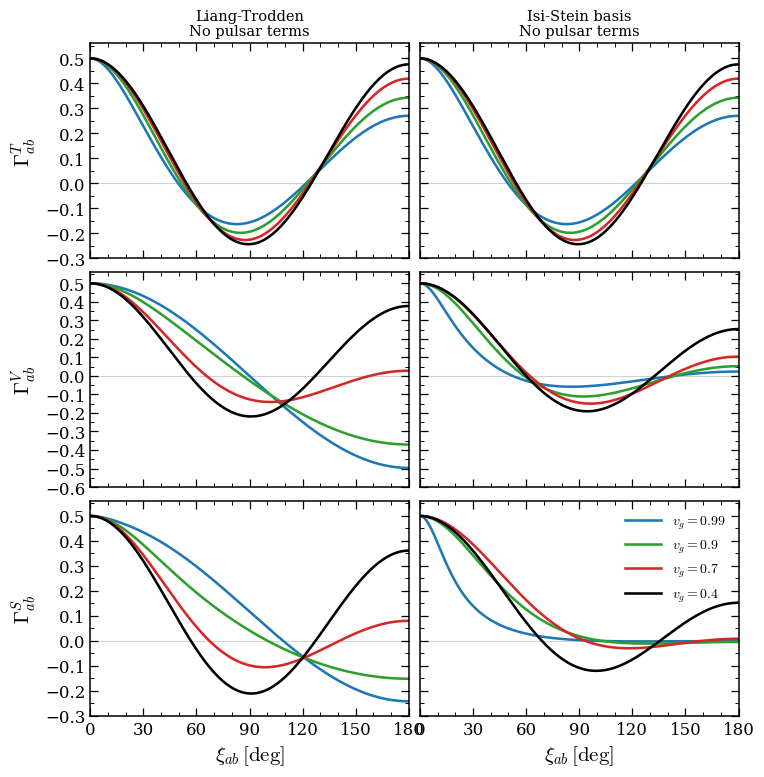

/Users/chrischoi/Work/research/polarization/suppression_paper_code/figs/liang_old_vs_isi_normalized_grid.pdf


In [3]:
plt.rcdefaults()
plt.rcParams.update(
    {
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "font.size": 12,
        "axes.labelsize": 15,
        "axes.titlesize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 10,
        "axes.linewidth": 1.1,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "xtick.minor.visible": True,
        "ytick.minor.visible": True,
        "savefig.dpi": 400,
    }
)

# Speeds and colors used in both ORF conventions.
vg_values = [0.99, 0.9, 0.7, 0.4]
vg_colors = {
    0.99: "#1f77b4",
    0.9: "#2ca02c",
    0.7: "#d62728",
    0.4: "#000000",
}
VG_VALUES = vg_values  # Used by the integral routines defined above.
sector_labels = {"tensor": "T", "vector": "V", "scalar": "S"}
panel_columns = (
    ("liang_earth", "Liang-Trodden\nNo pulsar terms"),
    ("isi_earth", "Isi-Stein basis\nNo pulsar terms"),
)

# Evaluate both sets of no-pulsar-term ORFs.
xi_values = np.linspace(0.0, np.pi, 750)
xi_degrees = np.degrees(xi_values)
quadrature = make_quadrature(n_mu=180, n_phi=180)
verify_liang_analytic_expressions(quadrature)

sectors = ("tensor", "vector", "scalar")
earth_curves = {
    "liang_earth": {
        sector: normalized_liang_earth_curves(sector, xi_values, quadrature)
        for sector in sectors
    },
    "isi_earth": {
        sector: normalized_isi_earth_curves(sector, xi_values, quadrature)
        for sector in sectors
    },
}

# Make the 3 x 2 paper figure explicitly in this cell.
fig, axes = plt.subplots(
    3,
    2,
    figsize=(7.1, 7.8),
    sharex=True,
    gridspec_kw={"wspace": 0.035, "hspace": 0.065},
)
fig.subplots_adjust(left=0.082, right=0.995, bottom=0.068, top=0.93)

for row, sector in enumerate(sectors):
    for col, (convention, convention_label) in enumerate(panel_columns):
        ax = axes[row, col]
        for vg in vg_values:
            ax.plot(
                xi_degrees,
                earth_curves[convention][sector][vg],
                color=vg_colors[vg],
                lw=1.85,
                label=rf"$v_g={vg:g}$",
            )

        ax.axhline(0.0, color="0.82", lw=0.8, zorder=0)
        ax.set_xlim(0.0, 180.0)
        ax.xaxis.set_major_locator(mticker.MultipleLocator(30.0))
        ax.xaxis.set_minor_locator(mticker.MultipleLocator(10.0))
        ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
        ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.05))
        ax.tick_params(which="major", length=5.5, width=0.9)
        ax.tick_params(which="minor", length=3.0, width=0.7)

        if sector == "tensor":
            ax.set_ylim(-0.3, 0.56)
        elif sector == "vector":
            ax.set_ylim(-0.6, 0.56)
        else:
            ax.set_ylim(-0.3, 0.56)

        if col == 1:
            ax.tick_params(axis="y", which="both", labelleft=False, labelright=False)
        if row == 0:
            ax.set_title(convention_label, fontsize=10.5, linespacing=1.1)
        if col == 0:
            ax.set_ylabel(rf"$\Gamma^{{{sector_labels[sector]}}}_{{ab}}$")
        if row == 2:
            ax.set_xlabel(r"$\xi_{ab}\,[{\rm deg}]$")

axes[2, 1].legend(frameon=False, loc="upper right", handlelength=2.6)

output = FIG_DIR / "liang_old_vs_isi_normalized_grid.pdf"
fig.savefig(output, bbox_inches="tight")
plt.show()
plt.close(fig)
print(output)


## Figure 2: tensor distance coherence and NANOGrav distance uncertainties


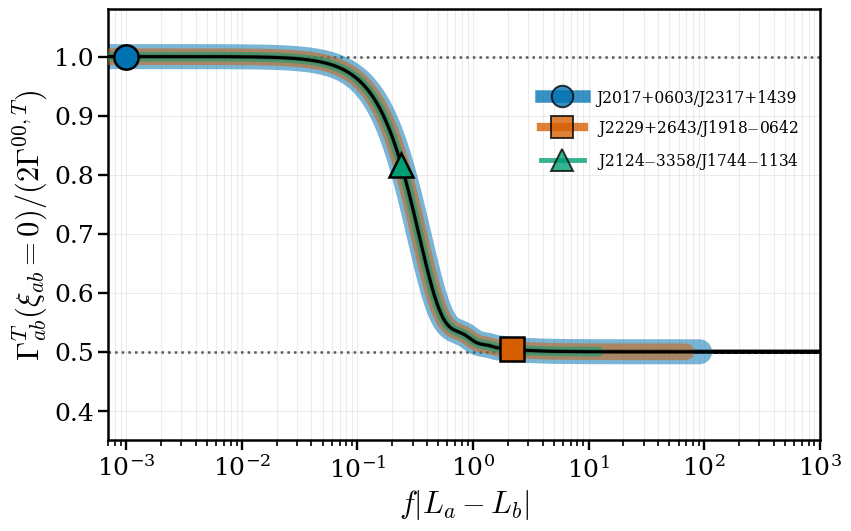

/Users/chrischoi/Work/research/polarization/suppression_paper_code/figs/tensor_gr_distance_coherence_paper.pdf
/Users/chrischoi/Work/research/polarization/suppression_paper_code/data/tensor_gr_distance_coherence_paper.csv
/Users/chrischoi/Work/research/polarization/suppression_paper_code/data/tensor_gr_distance_coherence_paper_pair_markers.csv
                    label  Gamma_T_EE_norm_xi0  Gamma_marg_q16  Gamma_marg_q50  Gamma_marg_q84  Gamma_marg_q02p5  Gamma_marg_q97p5
    J2017+0603/J2317+1439             1.000000        0.500001        0.500005        0.500054           0.50000          0.502315
  J2229+2643/J1918$-$0642             0.503898        0.500002        0.500009        0.500102           0.50000          0.504379
J2124$-$3358/J1744$-$1134             0.817104        0.500061        0.500278        0.503269           0.50002          0.658902


In [4]:
# Figure-specific GR coherence equations and positive-distance draws.
def normalized_cosine_transform(fL: np.ndarray | float) -> np.ndarray:
    """Cosine transform of the GR tensor xi=0 angular kernel.

    This is C(k)/C(0) = 3(2k - sin(2k))/(4k^3), with k=2 pi fL.
    A series expansion avoids cancellation at fL=0.
    """
    k = 2.0 * np.pi * np.abs(np.asarray(fL, dtype=float))
    out = np.empty_like(k)
    small = k < 1.0e-3
    k2 = k[small] ** 2
    out[small] = 1.0 - k2 / 5.0 + 2.0 * k2**2 / 105.0
    kk = k[~small]
    out[~small] = 3.0 * (2.0 * kk - np.sin(2.0 * kk)) / (4.0 * kk**3)
    return out

def tensor_gr_xi0_normalized(
    fL_a: np.ndarray | float,
    fL_b: np.ndarray | float,
) -> np.ndarray:
    """Exact Gamma_ab^T(xi=0)/(2 Gamma_ab^{00,T}(0)) in GR."""
    fL_a = np.asarray(fL_a, dtype=float)
    fL_b = np.asarray(fL_b, dtype=float)
    return 0.5 * (
        1.0
        - normalized_cosine_transform(fL_a)
        - normalized_cosine_transform(fL_b)
        + normalized_cosine_transform(fL_a - fL_b)
    )

def positive_normal_draws(
    rng: np.random.Generator,
    mean: float,
    sigma: float,
    size: int,
) -> np.ndarray:
    """Gaussian distance approximation, truncated only at physical L>0."""
    draws = rng.normal(mean, sigma, size)
    invalid = draws <= 0.0
    while np.any(invalid):
        draws[invalid] = rng.normal(mean, sigma, int(np.count_nonzero(invalid)))
        invalid = draws <= 0.0
    return draws


KPC_TO_LY = 3261.563776944
F_LOW_PER_YR = 1.0 / 15.0
PAIR_MARKERS = [
    ("J2017+0603/J2317+1439", 1.57, 0.31, 1.57, 0.29, "o", "#0072B2"),
    ("J2229+2643/J1918$-$0642", 1.43, 0.29, 1.44, 0.11, "s", "#D55E00"),
    ("J2124$-$3358/J1744$-$1134", 0.4130, 0.055, 0.4141, 0.0093, "^", "#009E73"),
]
ENVELOPE_WIDTHS = (18.0, 12.0, 7.0)

plt.rcdefaults()

vg = 1.0
fL_a = 500.0
# Begin below the visible log-axis limit so the curve and envelopes are
# clipped flush against the y-axis rather than leaving an artificial gap.
delta_fL = np.geomspace(1.0e-5, 1.0e5, 1_100)
distance_draws = 250_000
seed = 20260723
gamma_ee0 = 2.0 * np.pi / 3.0

rows = []
fL_b = fL_a + delta_fL
ee_norm = np.full_like(delta_fL, 0.5)
pe_norm = 0.5 * normalized_cosine_transform(fL_a) * np.ones_like(delta_fL)
ep_norm = 0.5 * normalized_cosine_transform(fL_b)
pp_norm = 0.5 * normalized_cosine_transform(delta_fL)
gamma_norm = ee_norm - pe_norm - ep_norm + pp_norm

pair_rows = []
rng = np.random.default_rng(seed)
for label, la_kpc, sigma_a_kpc, lb_kpc, sigma_b_kpc, marker, color in PAIR_MARKERS:
    pair_fL_a = F_LOW_PER_YR * la_kpc * KPC_TO_LY
    pair_fL_b = F_LOW_PER_YR * lb_kpc * KPC_TO_LY
    la_draws = positive_normal_draws(rng, la_kpc, sigma_a_kpc, distance_draws)
    lb_draws = positive_normal_draws(rng, lb_kpc, sigma_b_kpc, distance_draws)
    fL_a_draws = F_LOW_PER_YR * la_draws * KPC_TO_LY
    fL_b_draws = F_LOW_PER_YR * lb_draws * KPC_TO_LY
    delta_draws = np.abs(fL_a_draws - fL_b_draws)
    gamma_draws = tensor_gr_xi0_normalized(fL_a_draws, fL_b_draws)
    delta_q = np.quantile(delta_draws, [0.025, 0.16, 0.50, 0.84, 0.975])
    gamma_q = np.quantile(gamma_draws, [0.025, 0.16, 0.50, 0.84, 0.975])
    point_gamma = float(tensor_gr_xi0_normalized(pair_fL_a, pair_fL_b))
    delta_kpc = abs(la_kpc - lb_kpc)
    sigma_delta_quadrature_kpc = float(np.hypot(sigma_a_kpc, sigma_b_kpc))
    delta_min_quadrature_kpc = max(0.0, delta_kpc - sigma_delta_quadrature_kpc)
    delta_max_quadrature_kpc = delta_kpc + sigma_delta_quadrature_kpc
    delta_fL_min_quadrature = (
        F_LOW_PER_YR * KPC_TO_LY * delta_min_quadrature_kpc
    )
    delta_fL_max_quadrature = (
        F_LOW_PER_YR * KPC_TO_LY * delta_max_quadrature_kpc
    )

    # Retain the more conservative endpoint box as a CSV diagnostic, but
    # do not use it for the displayed statistical one-sigma envelope.
    sigma_sum_kpc = sigma_a_kpc + sigma_b_kpc
    delta_min_box_kpc = max(0.0, delta_kpc - sigma_sum_kpc)
    delta_max_box_kpc = delta_kpc + sigma_sum_kpc
    if la_kpc <= lb_kpc:
        delta_toward_endpoint_kpc = abs(
            (la_kpc + sigma_a_kpc) - (lb_kpc - sigma_b_kpc)
        )
        delta_apart_endpoint_kpc = abs(
            (la_kpc - sigma_a_kpc) - (lb_kpc + sigma_b_kpc)
        )
    else:
        delta_toward_endpoint_kpc = abs(
            (lb_kpc + sigma_b_kpc) - (la_kpc - sigma_a_kpc)
        )
        delta_apart_endpoint_kpc = abs(
            (lb_kpc - sigma_b_kpc) - (la_kpc + sigma_a_kpc)
        )
    delta_fL_min_box = F_LOW_PER_YR * KPC_TO_LY * delta_min_box_kpc
    delta_fL_max_box = F_LOW_PER_YR * KPC_TO_LY * delta_max_box_kpc
    pair_rows.append(
        {
            "label": label,
            "la_kpc": la_kpc,
            "sigma_a_kpc": sigma_a_kpc,
            "lb_kpc": lb_kpc,
            "sigma_b_kpc": sigma_b_kpc,
            "fL_a": pair_fL_a,
            "fL_b": pair_fL_b,
            "delta_fL": abs(pair_fL_a - pair_fL_b),
            "plot_x": max(abs(pair_fL_a - pair_fL_b), 1.0e-3),
            "Gamma_T_EE_norm_xi0": point_gamma,
            "sigma_delta_quadrature_kpc": sigma_delta_quadrature_kpc,
            "delta_min_1sigma_quadrature_kpc": delta_min_quadrature_kpc,
            "delta_max_1sigma_quadrature_kpc": delta_max_quadrature_kpc,
            "delta_fL_min_1sigma_quadrature": delta_fL_min_quadrature,
            "delta_fL_max_1sigma_quadrature": delta_fL_max_quadrature,
            "sigma_sum_kpc": sigma_sum_kpc,
            "delta_toward_endpoint_kpc": delta_toward_endpoint_kpc,
            "delta_apart_endpoint_kpc": delta_apart_endpoint_kpc,
            "delta_min_1sigma_box_kpc": delta_min_box_kpc,
            "delta_max_1sigma_box_kpc": delta_max_box_kpc,
            "delta_fL_min_1sigma_box": delta_fL_min_box,
            "delta_fL_max_1sigma_box": delta_fL_max_box,
            "delta_fL_q02p5": delta_q[0],
            "delta_fL_q16": delta_q[1],
            "delta_fL_q50": delta_q[2],
            "delta_fL_q84": delta_q[3],
            "delta_fL_q97p5": delta_q[4],
            "Gamma_marg_q02p5": gamma_q[0],
            "Gamma_marg_q16": gamma_q[1],
            "Gamma_marg_q50": gamma_q[2],
            "Gamma_marg_q84": gamma_q[3],
            "Gamma_marg_q97p5": gamma_q[4],
            "prob_Gamma_gt_0p75": float(np.mean(gamma_draws > 0.75)),
            "distance_draws": distance_draws,
            "distance_model": "independent positive-truncated Gaussian",
            "marker": marker,
            "color": color,
        }
    )
rows.append(
    pd.DataFrame(
        {
            "fL_a": fL_a,
            "delta_fL": delta_fL,
            "fL_b": fL_b,
            "v_g": vg,
            "num_samples": 0,
            "seed": seed,
            "Gamma_T_EE_xi0": gamma_ee0,
            "Gamma_T_full_xi0": 2.0 * gamma_ee0 * gamma_norm,
            "Gamma_T_EE_norm_xi0": gamma_norm,
            "Gamma_T_EE_piece_over_2EE0": ee_norm,
            "Gamma_T_PE_piece_over_2EE0": pe_norm,
            "Gamma_T_EP_piece_over_2EE0": ep_norm,
            "Gamma_T_PP_piece_over_2EE0": pp_norm,
            "method": "exact GR tensor xi=0 angular integral",
        }
    )
)

df = pd.concat(rows, ignore_index=True)
out_csv = DATA_DIR / "tensor_gr_distance_coherence_paper.csv"
df.to_csv(out_csv, index=False)
out_pairs_csv = DATA_DIR / "tensor_gr_distance_coherence_paper_pair_markers.csv"
pd.DataFrame(pair_rows).to_csv(out_pairs_csv, index=False)

plt.rcParams.update(
    {
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "font.size": 19,
        "axes.labelsize": 22,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "axes.linewidth": 1.8,
        "savefig.dpi": 300,
    }
)

fig, ax = plt.subplots(figsize=(8.4, 5.2), constrained_layout=True)
ax.plot(delta_fL, gamma_norm, color="black", lw=3.2)

ax.axhline(1.0, color="0.35", lw=1.8, ls=":")
ax.axhline(0.5, color="0.35", lw=1.8, ls=":")
ax.set_xscale("log")
ax.set_xlim(7.0e-4, 1.0e3)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=12))
ax.xaxis.set_major_formatter(LogFormatterMathtext(base=10.0))
ax.set_ylim(0.35, 1.08)
ax.set_xlabel(r"$f|L_a-L_b|$")
ax.set_ylabel(r"$\Gamma_{ab}^{T}(\xi_{ab}=0)/(2\Gamma^{00,T})$")
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.grid(True, which="both", alpha=0.24, linewidth=0.8)
ax.tick_params(axis="both", which="major", width=1.7, length=7)
ax.tick_params(axis="both", which="minor", width=1.2, length=4)

# Statistical one-sigma propagation for independent distance errors:
# sigma_DeltaL = sqrt(sigma_a^2 + sigma_b^2). Intervals that cross
# La=Lb are clipped at zero because the horizontal coordinate is |La-Lb|.
# Draw back-to-front in catalog order: blue, then orange, then green.
for layer_index, (pair, envelope_width) in enumerate(
    zip(pair_rows, ENVELOPE_WIDTHS)
):
    lo = max(pair["delta_fL_min_1sigma_quadrature"], delta_fL[0])
    hi = pair["delta_fL_max_1sigma_quadrature"]
    mask = (delta_fL >= lo) & (delta_fL <= hi)
    ax.plot(
        delta_fL[mask],
        gamma_norm[mask],
        color=pair["color"],
        lw=envelope_width,
        alpha=0.52,
        solid_capstyle="round",
        zorder=2 + layer_index,
    )

# Keep the nominal coherence curve visible through overlapping envelopes.
ax.plot(delta_fL, gamma_norm, color="black", lw=2.2, zorder=5)

for layer_index, pair in enumerate(pair_rows):
    # Filled marker: value at the catalog central distances.
    ax.plot(
        pair["plot_x"],
        pair["Gamma_T_EE_norm_xi0"],
        marker=pair["marker"],
        color=pair["color"],
        mec="black",
        mew=1.8,
        ms=17.5,
        linestyle="none",
        zorder=6 + layer_index,
    )

pair_handles = [
    Line2D(
        [],
        [],
        marker=pair["marker"],
        color=pair["color"],
        markeredgecolor="black",
        markeredgewidth=1.4,
        markersize=15.5,
        lw=envelope_width / 2.0,
        alpha=0.78,
        label=pair["label"],
    )
    for pair, envelope_width in zip(pair_rows, ENVELOPE_WIDTHS)
]
ax.legend(
    handles=pair_handles,
    frameon=False,
    fontsize=11.2,
    loc="center right",
    bbox_to_anchor=(0.99, 0.72),
    handlelength=2.8,
    labelspacing=0.75,
)

out_base = FIG_DIR / "tensor_gr_distance_coherence_paper"
fig.savefig(out_base.with_suffix(".pdf"), bbox_inches="tight")
plt.show()
print(out_base.with_suffix(".pdf"))
print(out_csv)
print(out_pairs_csv)
print(
    pd.DataFrame(pair_rows)[
        [
            "label",
            "Gamma_T_EE_norm_xi0",
            "Gamma_marg_q16",
            "Gamma_marg_q50",
            "Gamma_marg_q84",
            "Gamma_marg_q02p5",
            "Gamma_marg_q97p5",
        ]
    ].to_string(index=False)
)


## Figure 3: massive-limit finite-distance factor


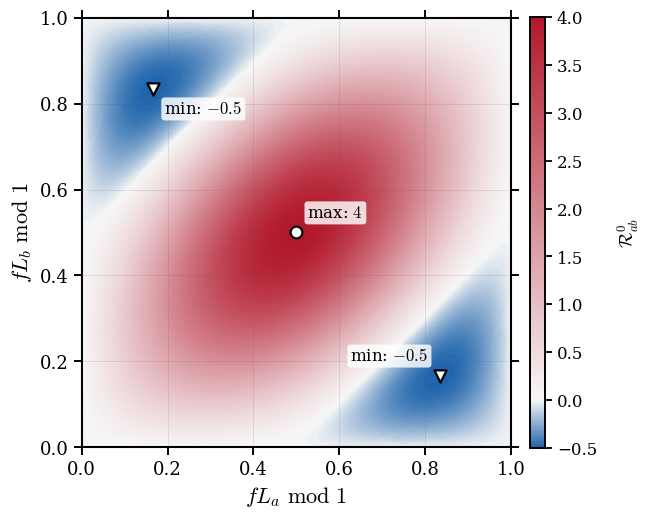

/Users/chrischoi/Work/research/polarization/suppression_paper_code/figs/re_pulsar_prod.pdf
range=[-0.5, 4]


In [5]:
plt.rcdefaults()

OUTPUT_DIR = FIG_DIR
OUTPUT_STEM = OUTPUT_DIR / "re_pulsar_prod"

plt.rcParams.update(
    {
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "font.size": 13,
        "axes.labelsize": 16,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "axes.linewidth": 1.5,
        "savefig.dpi": 350,
    }
)

grid = np.linspace(0.0, 1.0, 301)
f_l_a, f_l_b = np.meshgrid(grid, grid, indexing="xy")
values = (
    1.0
    - np.cos(2.0 * np.pi * f_l_a)
    - np.cos(2.0 * np.pi * f_l_b)
    + np.cos(2.0 * np.pi * (f_l_a - f_l_b))
)

fig, ax = plt.subplots(figsize=(6.8, 5.6), facecolor="white")
norm = Normalize(vmin=-0.5, vmax=4.0)
zero_position = (0.0 - norm.vmin) / (norm.vmax - norm.vmin)
blue_red = LinearSegmentedColormap.from_list(
    "phase_blue_red",
    [
        (0.0, "#2166ac"),
        (zero_position, "#f7f7f7"),
        (1.0, "#b2182b"),
    ],
)
surface = ax.pcolormesh(
    f_l_a,
    f_l_b,
    values,
    cmap=blue_red,
    norm=norm,
    shading="gouraud",
    rasterized=True,
)

maximum = np.asarray([[0.5, 0.5]])
minima = np.asarray(
    [
        [1.0 / 6.0, 5.0 / 6.0],
        [5.0 / 6.0, 1.0 / 6.0],
    ]
)
ax.scatter(
    maximum[:, 0],
    maximum[:, 1],
    facecolor="white",
    edgecolor="black",
    linewidth=1.6,
    marker="o",
    s=72,
    zorder=10,
)
ax.scatter(
    minima[:, 0],
    minima[:, 1],
    facecolor="white",
    edgecolor="black",
    linewidth=1.6,
    marker="v",
    s=78,
    zorder=10,
)
annotation_style = {
    "fontsize": 12,
    "color": "black",
    "bbox": {
        "boxstyle": "round,pad=0.18",
        "facecolor": "white",
        "edgecolor": "none",
        "alpha": 0.82,
    },
}
ax.annotate(
    r"max: $4$",
    xy=(0.5, 0.5),
    xytext=(8, 8),
    textcoords="offset points",
    ha="left",
    va="bottom",
    **annotation_style,
)
ax.annotate(
    r"min: $-0.5$",
    xy=(1.0 / 6.0, 5.0 / 6.0),
    xytext=(8, -8),
    textcoords="offset points",
    ha="left",
    va="top",
    **annotation_style,
)
ax.annotate(
    r"min: $-0.5$",
    xy=(5.0 / 6.0, 1.0 / 6.0),
    xytext=(-8, 8),
    textcoords="offset points",
    ha="right",
    va="bottom",
    **annotation_style,
)

ax.set_xlabel(r"$fL_a\ {\rm mod}\ 1$")
ax.set_ylabel(r"$fL_b\ {\rm mod}\ 1$")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_aspect("equal", adjustable="box")
ax.xaxis.set_major_locator(MultipleLocator(0.2))
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.tick_params(
    direction="out",
    top=True,
    right=True,
    width=1.4,
    length=6,
)
ax.set_axisbelow(False)
ax.grid(
    True,
    which="major",
    color="#4b5563",
    linewidth=0.7,
    alpha=0.14,
)

colorbar = fig.colorbar(surface, ax=ax, pad=0.035, aspect=28)
colorbar.set_label(
    r"$\mathcal{R}_{ab}^{0}$",
    fontsize=13,
    labelpad=14,
)
colorbar.set_ticks(np.arange(-0.5, 4.01, 0.5))
colorbar.ax.tick_params(width=1.3, length=5, labelsize=12)
colorbar.outline.set_linewidth(1.4)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT_STEM.with_suffix(".pdf"), bbox_inches="tight")
plt.show()
plt.close(fig)

print(OUTPUT_STEM.with_suffix(".pdf"))
print(f"range=[{values.min():.12g}, {values.max():.12g}]")


## Figure 4: massive-limit angular shapes


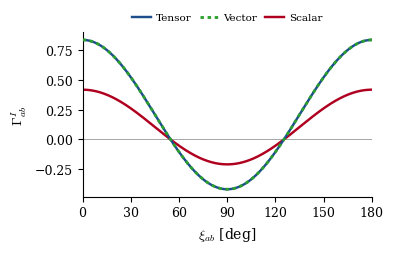

Wrote /Users/chrischoi/Work/research/polarization/suppression_paper_code/figs/massive_limit_angular_shapes.pdf


In [6]:
plt.rcdefaults()

plt.rcParams.update(
    {
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "font.size": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 7.5,
        "axes.linewidth": 0.8,
    }
)

xi_deg = np.linspace(0.0, 180.0, 500)
xi_rad = np.radians(xi_deg)
quad = 0.5 * (3.0 * np.cos(xi_rad) ** 2 - 1.0)

gamma_t = (4.0 * np.pi / 15.0) * quad
gamma_v = (4.0 * np.pi / 15.0) * quad
gamma_s = (2.0 * np.pi / 15.0) * quad

curves = [
    ("Tensor", gamma_t, "#1f4e8c", "-", 1.75, 3),
    ("Vector", gamma_v, "#2ca02c", (0, (1.2, 1.3)), 2.05, 4),
    ("Scalar", gamma_s, "#b00020", "-", 1.75, 2),
]

fig, ax = plt.subplots(figsize=(3.55, 2.65))
for label, values, color, linestyle, lw, zorder in curves:
    ax.plot(xi_deg, values, color=color, ls=linestyle, lw=lw, label=label, zorder=zorder)

ax.axhline(0.0, color="0.65", lw=0.7, zorder=0)
ax.set_xlim(0, 180)
ax.set_xticks([0, 30, 60, 90, 120, 150, 180])
ax.set_xlabel(r"$\xi_{ab}$ [deg]")
ax.set_ylabel(r"$\Gamma_{ab}^{I}$")
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.035),
    ncol=3,
    frameon=False,
    handlelength=1.8,
    handletextpad=0.45,
    columnspacing=0.8,
    borderaxespad=0.0,
)
ax.spines[["top", "right"]].set_visible(False)
fig.subplots_adjust(left=0.17, right=0.985, bottom=0.18, top=0.80)

output = FIG_DIR / "massive_limit_angular_shapes.pdf"
output.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Wrote {output}")


## Figure 5: massless-limit angular shapes with pulsar terms


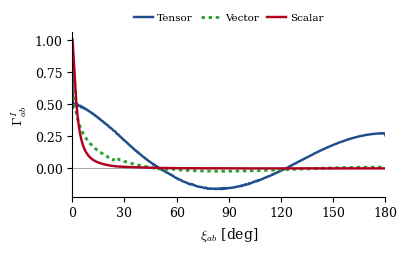

Wrote /Users/chrischoi/Work/research/polarization/suppression_paper_code/figs/massless_limit_angular_shapes.pdf


In [7]:
plt.rcdefaults()

plt.rcParams.update(
    {
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "font.size": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 7.5,
        "axes.linewidth": 0.8,
    }
)

xi_deg = np.linspace(0.0, 180.0, 500)
xi_rad = np.radians(xi_deg)
gamma_t, gamma_v_rescaled, gamma_s_rescaled = corrected_finite_distance_coefficients(xi_rad)
gamma_t = gamma_t / gamma_t[0]
gamma_v_rescaled = gamma_v_rescaled / gamma_v_rescaled[0]
gamma_s_rescaled = gamma_s_rescaled / gamma_s_rescaled[0]

curves = [
    ("Tensor", gamma_t, "#1f4e8c", "-", 1.75),
    ("Vector", gamma_v_rescaled, "#2ca02c", (0, (1.2, 1.3)), 2.05),
    ("Scalar", gamma_s_rescaled, "#b00020", "-", 1.75),
]

fig, ax = plt.subplots(figsize=(3.75, 2.65))
for label, values, color, linestyle, lw in curves:
    ax.plot(xi_deg, values, color=color, ls=linestyle, lw=lw, label=label)

ax.axhline(0.0, color="0.65", lw=0.7, zorder=0)
ax.set_xlim(0, 180)
ax.set_xticks([0, 30, 60, 90, 120, 150, 180])
ax.set_xlabel(r"$\xi_{ab}$ [deg]")
ax.set_ylabel(r"$\Gamma_{ab}^{I}$")
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.035),
    ncol=3,
    frameon=False,
    handlelength=1.8,
    handletextpad=0.45,
    columnspacing=0.8,
    borderaxespad=0.0,
)
ax.spines[["top", "right"]].set_visible(False)
fig.subplots_adjust(left=0.15, right=0.985, bottom=0.18, top=0.80)

output = FIG_DIR / "massless_limit_angular_shapes.pdf"
output.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Wrote {output}")


## Figure 6: finite-distance autocorrelations versus $fL$


Using cached autocorrelation curves: /Users/chrischoi/Work/research/polarization/suppression_paper_code/data/autocorrelation_finite_distance_plot_cache.npz


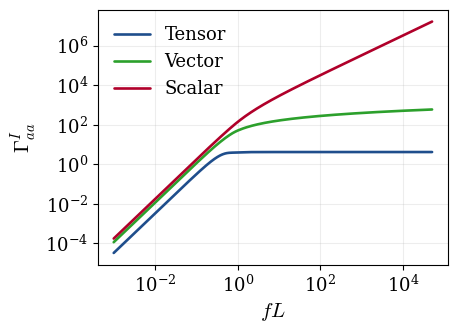

/Users/chrischoi/Work/research/polarization/suppression_paper_code/figs/autocorrelation_finite_distance_fL.pdf


In [8]:
plt.rcdefaults()
plt.rcParams.update(
    {
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "font.size": 14,
        "axes.labelsize": 15,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 13,
        "lines.solid_capstyle": "round",
        "savefig.dpi": 300,
    }
)

# Load the archived exact-integral curves when their metadata matches.
distance_table = DATA_DIR / "nanograv15_table2_distances.csv"
cache_path = DATA_DIR / "autocorrelation_finite_distance_plot_cache.npz"
cache_version = 14
autocorr_curves = None

if cache_path.exists():
    with np.load(cache_path) as cache:
        if (
            "cache_version" in cache.files
            and int(cache["cache_version"]) == cache_version
            and float(cache["T_obs_yr"]) == T_OBS_YR
        ):
            autocorr_curves = {name: cache[name] for name in cache.files}
            print(f"Using cached autocorrelation curves: {cache_path}")

# The fallback below explicitly rebuilds the cache from the retained distance
# table and the exact finite-fL integral routines in the second cell.
if autocorr_curves is None:
    with distance_table.open() as handle:
        distance_rows = list(csv.DictReader(handle))

    distances_ly = np.asarray([float(row["d_ly"]) for row in distance_rows])
    median_ly = float(np.median(distances_ly))
    furthest_row = max(distance_rows, key=lambda row: float(row["d_ly"]))
    closest_row = min(distance_rows, key=lambda row: float(row["d_ly"]))

    furthest_name = furthest_row["name"]
    furthest_ly = float(furthest_row["d_ly"])
    furthest_err_ly = float(furthest_row["d_err_ly"])
    closest_name = closest_row["name"]
    closest_ly = float(closest_row["d_ly"])
    closest_err_ly = float(closest_row["d_err_ly"])

    n_gwb_freqs = 14
    high_f_l_reference = n_gwb_freqs * furthest_ly / T_OBS_YR
    high_f_l_reference_err = n_gwb_freqs * furthest_err_ly / T_OBS_YR
    low_f_l_reference = closest_ly / T_OBS_YR
    low_f_l_reference_err = closest_err_ly / T_OBS_YR

    f_l_grid = np.geomspace(1.0e-3, 5.0e4, 1400)
    f_l_tensor, f_l_vector, f_l_scalar = autocorrelation_vg1_rescaled(f_l_grid)

    endpoint_grid = 1.0 - np.geomspace(1.0e-8, 1.0e-1, 360)
    v_grid = np.unique(
        np.concatenate(
            [
                np.linspace(1.0e-6, 0.9, 181),
                np.linspace(0.9, 0.99, 181),
                endpoint_grid,
            ]
        )
    )
    high_v_tensor = np.empty_like(v_grid)
    high_v_vector = np.empty_like(v_grid)
    high_v_scalar = np.empty_like(v_grid)
    low_v_tensor = np.empty_like(v_grid)
    low_v_vector = np.empty_like(v_grid)
    low_v_scalar = np.empty_like(v_grid)

    for idx, v_g in enumerate(v_grid):
        high_v_tensor[idx], high_v_vector[idx], high_v_scalar[idx] = (
            rescaled_autocorrelation_exact(high_f_l_reference, float(v_g))
        )
        low_v_tensor[idx], low_v_vector[idx], low_v_scalar[idx] = (
            rescaled_autocorrelation_exact(low_f_l_reference, float(v_g))
        )

    one_minus_v_grid = np.geomspace(1.0e-8, 9.99e-1, 901, dtype=np.float64)
    high_one_minus_v_tensor = np.empty_like(one_minus_v_grid)
    high_one_minus_v_vector = np.empty_like(one_minus_v_grid)
    high_one_minus_v_scalar = np.empty_like(one_minus_v_grid)
    low_one_minus_v_tensor = np.empty_like(one_minus_v_grid)
    low_one_minus_v_vector = np.empty_like(one_minus_v_grid)
    low_one_minus_v_scalar = np.empty_like(one_minus_v_grid)

    for idx, one_minus_v in enumerate(one_minus_v_grid):
        (
            high_one_minus_v_tensor[idx],
            high_one_minus_v_vector[idx],
            high_one_minus_v_scalar[idx],
        ) = rescaled_autocorrelation_one_minus_v(
            high_f_l_reference, float(one_minus_v)
        )
        (
            low_one_minus_v_tensor[idx],
            low_one_minus_v_vector[idx],
            low_one_minus_v_scalar[idx],
        ) = rescaled_autocorrelation_one_minus_v(
            low_f_l_reference, float(one_minus_v)
        )

    autocorr_curves = {
        "cache_version": cache_version,
        "T_obs_yr": T_OBS_YR,
        "n_gwb_freqs": n_gwb_freqs,
        "median_distance_ly": median_ly,
        "furthest_pulsar": furthest_name,
        "furthest_distance_ly": furthest_ly,
        "furthest_distance_err_ly": furthest_err_ly,
        "closest_pulsar": closest_name,
        "closest_distance_ly": closest_ly,
        "closest_distance_err_ly": closest_err_ly,
        "high_reference_fL": high_f_l_reference,
        "high_reference_fL_err": high_f_l_reference_err,
        "low_reference_fL": low_f_l_reference,
        "low_reference_fL_err": low_f_l_reference_err,
        "f_l_grid": f_l_grid,
        "f_l_tensor": f_l_tensor,
        "f_l_vector": f_l_vector,
        "f_l_scalar": f_l_scalar,
        "v_grid": v_grid,
        "high_v_tensor": high_v_tensor,
        "high_v_vector": high_v_vector,
        "high_v_scalar": high_v_scalar,
        "low_v_tensor": low_v_tensor,
        "low_v_vector": low_v_vector,
        "low_v_scalar": low_v_scalar,
        "one_minus_v_grid": one_minus_v_grid,
        "high_one_minus_v_tensor": high_one_minus_v_tensor,
        "high_one_minus_v_vector": high_one_minus_v_vector,
        "high_one_minus_v_scalar": high_one_minus_v_scalar,
        "low_one_minus_v_tensor": low_one_minus_v_tensor,
        "low_one_minus_v_vector": low_one_minus_v_vector,
        "low_one_minus_v_scalar": low_one_minus_v_scalar,
    }
    np.savez_compressed(cache_path, **autocorr_curves)
    print(f"Wrote autocorrelation cache: {cache_path}")

# Plot Figure 6 directly.
f_l_grid = np.asarray(autocorr_curves["f_l_grid"], dtype=float)
fig, ax = plt.subplots(figsize=(4.8, 3.55))
ax.plot(f_l_grid, autocorr_curves["f_l_tensor"], color="#1f4e8c", lw=1.9, label="Tensor")
ax.plot(f_l_grid, autocorr_curves["f_l_vector"], color="#2ca02c", lw=1.9, label="Vector")
ax.plot(f_l_grid, autocorr_curves["f_l_scalar"], color="#b0002a", lw=1.9, label="Scalar")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$fL$")
ax.set_ylabel(r"$\Gamma_{aa}^{I}$")
ax.grid(alpha=0.22, which="both")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()

output = FIG_DIR / "autocorrelation_finite_distance_fL.pdf"
fig.savefig(output, bbox_inches="tight")
plt.show()
plt.close(fig)
print(output)


## Figure 7: finite-distance autocorrelations versus $1-v_g$


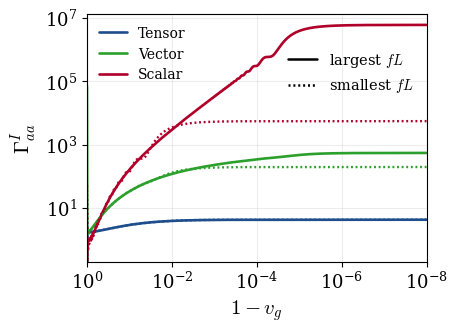

/Users/chrischoi/Work/research/polarization/suppression_paper_code/figs/autocorrelation_finite_distance_vg_scan.pdf
/Users/chrischoi/Work/research/polarization/suppression_paper_code/data/autocorrelation_finite_distance_plot_report.json


In [9]:
plt.rcdefaults()
plt.rcParams.update(
    {
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "font.size": 14,
        "axes.labelsize": 15,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "legend.fontsize": 13,
        "lines.solid_capstyle": "round",
        "savefig.dpi": 300,
    }
)

# Load the same exact-integral cache explicitly so this cell can be rerun on its own.
cache_path = DATA_DIR / "autocorrelation_finite_distance_plot_cache.npz"
with np.load(cache_path) as cache:
    autocorr_curves = {name: cache[name] for name in cache.files}

one_minus_v_grid = np.asarray(autocorr_curves["one_minus_v_grid"], dtype=float)
high_tensor = np.asarray(autocorr_curves["high_one_minus_v_tensor"], dtype=float)
high_vector = np.asarray(autocorr_curves["high_one_minus_v_vector"], dtype=float)
high_scalar = np.asarray(autocorr_curves["high_one_minus_v_scalar"], dtype=float)
low_tensor = np.asarray(autocorr_curves["low_one_minus_v_tensor"], dtype=float)
low_vector = np.asarray(autocorr_curves["low_one_minus_v_vector"], dtype=float)
low_scalar = np.asarray(autocorr_curves["low_one_minus_v_scalar"], dtype=float)
high_f_l_reference = float(autocorr_curves["high_reference_fL"])
low_f_l_reference = float(autocorr_curves["low_reference_fL"])

# Plot Figure 7 directly.
dense_dots = (0, (0.8, 1.15))
fig, ax = plt.subplots(figsize=(4.8, 3.55))
ax.plot(one_minus_v_grid, high_tensor, color="#1f4e8c", lw=1.9, ls="-", label="Tensor")
ax.plot(one_minus_v_grid, high_vector, color="#2ca02c", lw=1.9, ls="-", label="Vector")
ax.plot(one_minus_v_grid, high_scalar, color="#b0002a", lw=1.9, ls="-", label="Scalar")
ax.plot(one_minus_v_grid, low_tensor, color="#1f4e8c", lw=1.7, ls=dense_dots)
ax.plot(one_minus_v_grid, low_vector, color="#2ca02c", lw=1.7, ls=dense_dots)
ax.plot(one_minus_v_grid, low_scalar, color="#b0002a", lw=1.7, ls=dense_dots)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1.0, one_minus_v_grid.min())
ax.set_xlabel(r"$1-v_g$")
ax.set_ylabel(r"$\Gamma_{aa}^{I}$")
ax.grid(alpha=0.22, which="both")

mode_legend = ax.legend(frameon=False, loc="upper left", fontsize=10.0)
ax.add_artist(mode_legend)
style_handles = [
    Line2D([0], [0], color="black", lw=1.8, ls="-", label=r"largest $fL$"),
    Line2D([0], [0], color="black", lw=1.8, ls=dense_dots, label=r"smallest $fL$"),
]
ax.legend(
    handles=style_handles,
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(1.0, 0.90),
    fontsize=10.5,
)
fig.tight_layout()

output = FIG_DIR / "autocorrelation_finite_distance_vg_scan.pdf"
fig.savefig(output, bbox_inches="tight")
plt.show()
plt.close(fig)
print(output)

# Refresh the portable human-readable report alongside the cache.
f_l_grid = np.asarray(autocorr_curves["f_l_grid"], dtype=float)
v_grid = np.asarray(autocorr_curves["v_grid"], dtype=float)
report = {
    "T_obs_yr": T_OBS_YR,
    "median_distance_ly": float(autocorr_curves["median_distance_ly"]),
    "n_gwb_freqs": int(autocorr_curves["n_gwb_freqs"]),
    "furthest_pulsar": str(autocorr_curves["furthest_pulsar"]),
    "furthest_distance_ly": float(autocorr_curves["furthest_distance_ly"]),
    "furthest_distance_err_ly": float(autocorr_curves["furthest_distance_err_ly"]),
    "closest_pulsar": str(autocorr_curves["closest_pulsar"]),
    "closest_distance_ly": float(autocorr_curves["closest_distance_ly"]),
    "closest_distance_err_ly": float(autocorr_curves["closest_distance_err_ly"]),
    "high_reference_fL": high_f_l_reference,
    "high_reference_fL_err": float(autocorr_curves["high_reference_fL_err"]),
    "low_reference_fL": low_f_l_reference,
    "low_reference_fL_err": float(autocorr_curves["low_reference_fL_err"]),
    "fL_grid_min": float(f_l_grid.min()),
    "fL_grid_max": float(f_l_grid.max()),
    "v_grid_min": float(v_grid.min()),
    "v_grid_max": float(v_grid.max()),
    "v_grid_count": int(v_grid.size),
    "one_minus_v_grid_min": float(one_minus_v_grid.min()),
    "one_minus_v_grid_max": float(one_minus_v_grid.max()),
    "one_minus_v_grid_count": int(one_minus_v_grid.size),
    "one_minus_v_transition_low": float(1.0 / low_f_l_reference),
    "one_minus_v_transition_high": float(1.0 / high_f_l_reference),
    "vg_scan_method": "Exact finite-fL antiderivatives for the autocorrelation; grids approach but do not include v_g=0 or v_g=1",
    "cache": "data/autocorrelation_finite_distance_plot_cache.npz",
    "prefactor_note": "The vector curve is (1-v_g^2) Gamma_V and the scalar curve is (1-v_g^2)^2 Gamma_S.",
    "outputs": [
        "figs/autocorrelation_finite_distance_fL.pdf",
        "figs/autocorrelation_finite_distance_vg_scan.pdf",
    ],
}
report_path = DATA_DIR / "autocorrelation_finite_distance_plot_report.json"
report_path.write_text(
    json.dumps(report, indent=2, sort_keys=True)
)
print(report_path)


## Figure 8: vector/scalar sector-fraction heat maps


Using cached ORF powers: /Users/chrischoi/Work/research/polarization/suppression_paper_code/data/sector_fraction_alpha_n_orf_powers.npz


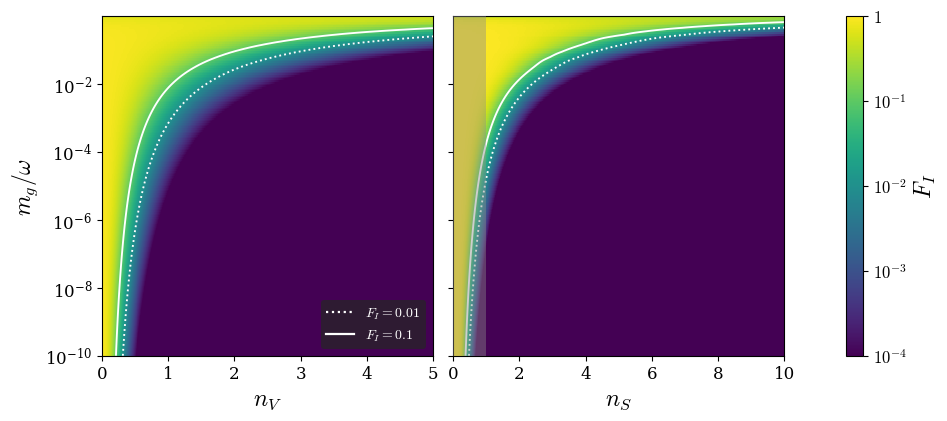

/Users/chrischoi/Work/research/polarization/suppression_paper_code/figs/sector_fraction_alpha_n_heatmap.pdf
/Users/chrischoi/Work/research/polarization/suppression_paper_code/data/sector_fraction_alpha_n_heatmap.csv


In [10]:
plt.rcdefaults()

# Numerical and physical choices used for the paper figure.
alpha_min = 1.0e-6
alpha_max = 0.999
n_alpha = 120
display_alpha_min = 1.0e-10
n_alpha_extrap = 160
n_asymptotic_average = 5
n_xi = 250
num_samples = 25000
seed = 0
xi_min_rad = 1.0e-3
f_nhz = 1.97679899027005
l1_ly = 500.0
l2_ly = 10000.0
spacing = 0.005
grid_max_v = 5.0
grid_max_s = 10.0
scalar_prefactor = 1.0
color_floor = 1.0e-4
contour_values = np.asarray([0.01, 0.1])
cache_version = 7
cache_path = DATA_DIR / "sector_fraction_alpha_n_orf_powers.npz"

expected_metadata = np.asarray(
    [
        f_nhz,
        l1_ly,
        l2_ly,
        num_samples,
        n_xi,
        xi_min_rad,
        alpha_min,
        alpha_max,
        n_alpha,
        seed,
        1.0,  # isotropic sin(xi) weighting
    ],
    dtype=float,
)

# Load the archived ORF powers when the physical and numerical metadata match.
powers = None
if cache_path.exists():
    with np.load(cache_path, allow_pickle=False) as cache:
        cached_version = int(cache["cache_version"][0])
        cached_metadata = cache["metadata"]
        if (
            cached_version == cache_version
            and cached_metadata.shape == expected_metadata.shape
            and np.allclose(cached_metadata, expected_metadata, rtol=0.0, atol=1.0e-12)
        ):
            powers = {
                "alpha_values": cache["alpha_values"],
                "tensor_power": cache["tensor_power"],
                "vector_reg_power": cache["vector_reg_power"],
                "scalar_reg_power": cache["scalar_reg_power"],
                "metadata": cache["metadata"],
            }
            print(f"Using cached ORF powers: {cache_path}")

# Comment out the cache-loading block above to force this direct ORF calculation.
if powers is None:
    fL1 = f_l_from_frequency_distance(f_nhz, l1_ly)
    fL2 = f_l_from_frequency_distance(f_nhz, l2_ly)
    xi_values = np.linspace(xi_min_rad, np.pi, n_xi)
    xi_weights = np.sin(xi_values)
    alpha_values = np.geomspace(alpha_min, alpha_max, n_alpha)
    a_values = np.asarray([alpha_safe_a_value(alpha) for alpha in alpha_values])

    tensor_power = np.empty(n_alpha)
    vector_reg_power = np.empty(n_alpha)
    scalar_reg_power = np.empty(n_alpha)

    for i, (alpha, a_value) in enumerate(zip(alpha_values, a_values)):
        raw_tensor = Gamma_T(
            1.0, a_value, xi_values, fL1, fL2, num_samples, seed
        )
        regularized_vector = Gamma_V_regularized(
            1.0, alpha, xi_values, fL1, fL2, num_samples, seed
        )
        regularized_scalar = Gamma_S_regularized(
            1.0, alpha, xi_values, fL1, fL2, num_samples, seed
        )

        tensor_power[i] = simpson(np.abs(raw_tensor) * xi_weights, x=xi_values)
        vector_reg_power[i] = simpson(
            np.abs(regularized_vector) * xi_weights, x=xi_values
        )
        scalar_reg_power[i] = simpson(
            np.abs(regularized_scalar) * xi_weights, x=xi_values
        )

        if (i + 1) % 10 == 0 or i == n_alpha - 1:
            print(f"Alpha grid {i + 1}/{n_alpha} complete")

    np.savez_compressed(
        cache_path,
        cache_version=np.asarray([cache_version], dtype=int),
        alpha_values=alpha_values,
        tensor_power=tensor_power,
        vector_reg_power=vector_reg_power,
        scalar_reg_power=scalar_reg_power,
        metadata=expected_metadata,
    )
    powers = {
        "alpha_values": alpha_values,
        "tensor_power": tensor_power,
        "vector_reg_power": vector_reg_power,
        "scalar_reg_power": scalar_reg_power,
        "metadata": expected_metadata,
    }

# Build the vector and scalar fraction grids explicitly.
alpha_values = np.asarray(powers["alpha_values"])
n_steps_v = int(round(grid_max_v / spacing))
n_steps_s = int(round(grid_max_s / spacing))
n_grid_v = np.round(np.linspace(0.0, n_steps_v * spacing, n_steps_v + 1), 10)
n_grid_s = np.round(np.linspace(0.0, n_steps_s * spacing, n_steps_s + 1), 10)

frac_v = np.empty((len(alpha_values), len(n_grid_v)))
frac_s = np.empty((len(alpha_values), len(n_grid_s)))
for i, alpha in enumerate(alpha_values):
    vector_sector_power = alpha**n_grid_v * powers["vector_reg_power"][i]
    scalar_sector_power = (
        scalar_prefactor * alpha**n_grid_s * powers["scalar_reg_power"][i]
    )
    frac_v[i] = vector_sector_power / (
        powers["tensor_power"][i] + vector_sector_power
    )
    frac_s[i] = scalar_sector_power / (
        powers["tensor_power"][i] + scalar_sector_power
    )

# Extend the displayed low-alpha region with the asymptotic powers already
# reached at the first few numerically evaluated alpha values.
alpha_extension = np.geomspace(
    display_alpha_min, alpha_values[0], n_alpha_extrap + 1
)[:-1]
tensor_asymptote = float(
    np.median(powers["tensor_power"][:n_asymptotic_average])
)
vector_asymptote = float(
    np.median(powers["vector_reg_power"][:n_asymptotic_average])
)
scalar_asymptote = float(
    np.median(powers["scalar_reg_power"][:n_asymptotic_average])
)

frac_v_extension = np.empty((len(alpha_extension), len(n_grid_v)))
frac_s_extension = np.empty((len(alpha_extension), len(n_grid_s)))
for i, alpha in enumerate(alpha_extension):
    vector_sector_power = alpha**n_grid_v * vector_asymptote
    scalar_sector_power = scalar_prefactor * alpha**n_grid_s * scalar_asymptote
    frac_v_extension[i] = vector_sector_power / (
        tensor_asymptote + vector_sector_power
    )
    frac_s_extension[i] = scalar_sector_power / (
        tensor_asymptote + scalar_sector_power
    )

alpha_values = np.concatenate([alpha_extension, alpha_values])
frac_v = np.vstack([frac_v_extension, frac_v])
frac_s = np.vstack([frac_s_extension, frac_s])

# Write the complete numerical grid behind the two panels.
table_rows = ["mode,alpha,n,F"]
for mode, values, n_grid in [
    ("V", frac_v, n_grid_v),
    ("S", frac_s, n_grid_s),
]:
    for i, alpha in enumerate(alpha_values):
        for n_value, fraction in zip(n_grid, values[i]):
            table_rows.append(
                f"{mode},{alpha:.12g},{n_value:.10g},{fraction:.12g}"
            )
table_path = DATA_DIR / "sector_fraction_alpha_n_heatmap.csv"
table_path.write_text("\n".join(table_rows) + "\n")

# Construct the heat-map cell edges directly.
log_alpha = np.log(alpha_values)
alpha_midpoints = 0.5 * (log_alpha[1:] + log_alpha[:-1])
alpha_edges = np.exp(
    np.concatenate(
        [
            [log_alpha[0] - (alpha_midpoints[0] - log_alpha[0])],
            alpha_midpoints,
            [log_alpha[-1] + (log_alpha[-1] - alpha_midpoints[-1])],
        ]
    )
)

plt.rcParams.update(
    {
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "font.size": 14,
        "axes.labelsize": 17,
        "axes.titlesize": 18,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "savefig.dpi": 300,
    }
)

# Plot the two panels explicitly.
fig, axes = plt.subplots(
    1, 2, figsize=(9.4, 4.1), sharey=True, constrained_layout=True
)
image = None
for ax, mode, fractions, n_grid in [
    (axes[0], "V", frac_v, n_grid_v),
    (axes[1], "S", frac_s, n_grid_s),
]:
    n_midpoints = 0.5 * (n_grid[1:] + n_grid[:-1])
    n_edges = np.concatenate(
        [
            [n_grid[0] - (n_midpoints[0] - n_grid[0])],
            n_midpoints,
            [n_grid[-1] + (n_grid[-1] - n_midpoints[-1])],
        ]
    )
    n_mesh, alpha_mesh = np.meshgrid(n_grid, alpha_values)
    log_fractions = np.log10(np.clip(fractions, color_floor, 1.0))

    image = ax.pcolormesh(
        n_edges,
        alpha_edges,
        log_fractions,
        cmap="viridis",
        shading="auto",
        vmin=np.log10(color_floor),
        vmax=0.0,
        rasterized=True,
    )
    ax.contour(
        n_mesh,
        alpha_mesh,
        log_fractions,
        levels=np.log10(np.sort(contour_values)),
        colors="white",
        linestyles=[":", "-"],
        linewidths=1.35,
    )
    ax.set_yscale("log")
    ax.set_xlabel(rf"$n_{mode}$")
    ax.set_xlim(float(n_grid.min()), float(n_grid.max()))
    ax.set_ylim(float(alpha_values.min()), float(alpha_values.max()))
    ax.grid(False)

axes[1].axvspan(
    float(n_grid_s.min()),
    1.0,
    facecolor="0.55",
    edgecolor="none",
    linewidth=0.0,
    alpha=0.42,
    zorder=5,
)
axes[0].set_ylabel(r"$m_g/\omega$")

cbar = fig.colorbar(image, ax=axes, pad=0.075, fraction=0.045)
cbar.set_label(r"$F_I$")
cbar_ticks = np.arange(int(np.log10(color_floor)), 1, 1)
cbar.set_ticks(cbar_ticks)
cbar.set_ticklabels(
    [rf"$10^{{{tick}}}$" if tick else "$1$" for tick in cbar_ticks]
)

contour_handles = [
    Line2D(
        [0],
        [0],
        color="white",
        lw=1.6,
        ls=style,
        label=rf"$F_I={value:g}$",
    )
    for value, style in zip(np.sort(contour_values), [":", "-"])
]
axes[0].legend(
    handles=contour_handles,
    loc="lower right",
    frameon=True,
    framealpha=0.72,
    facecolor="0.15",
    edgecolor="none",
    fontsize=10,
    labelcolor="white",
)

output = FIG_DIR / "sector_fraction_alpha_n_heatmap.pdf"
fig.savefig(output, bbox_inches="tight", pad_inches=0.04)
plt.show()
plt.close(fig)
print(output)
print(table_path)
